In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from scipy.spatial.distance import cdist
import constant as const

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
url = "http://127.0.0.1:80"
testcase = 'bestest_air'
testid = \
device = 'cuda'
print("Using:", device)
testid = \
requests.post('{0}/testcases/{1}/select'.format(url,testcase)).json()['testid']
name = requests.get('{0}/name/{1}'.format(url, testid)).json()['payload']
print(name)

Using: cuda
{'name': 'bestest_air'}


In [4]:
data = pd.read_csv(f'processed_uniform_low_step_5m_data.csv')
data.head()

T_zone = (data['zon_reaTRooAir_y'].values - 273.15) / 30.0
T_sup  = (data['fcu_oveTSup_u'].values - 273.15) / 40.0
fan  = data['fcu_oveFan_u'].values
T_out = (data['zon_weaSta_reaWeaTDryBul_y'].values - 273.15) / 10.0

pos_T_zone = T_zone[1:]
cur_T_zone = T_zone[:-1]
cur_T_sup = T_sup[:-1]
cur_fan = fan[:-1]
cur_T_out = T_out[:-1]

def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32, device=device)

def data_split(Ns, Ne, x1, x2, x3, x4, x5):
    return (to_tensor(x1[Ns:Ne]).view(-1,1), to_tensor(x2[Ns:Ne]).view(-1,1),
            to_tensor(x3[Ns:Ne]).view(-1,1), to_tensor(x4[Ns:Ne]).view(-1,1), to_tensor(x5[Ns:Ne]).view(-1,1))

Ns_tr, Ne_tr = const.Ns_tr, const.Ne_tr  
Ns_t, Ne_t = const.Ns_t, const.Ne_t 

cur_T_zone_tr, cur_T_sup_tr, cur_fan_tr, cur_T_out_tr, pos_T_zone_tr = data_split(Ns_tr, Ne_tr, cur_T_zone, cur_T_sup, cur_fan, cur_T_out, pos_T_zone)
cur_T_zone_t, cur_T_sup_t, cur_fan_t, cur_T_out_t, pos_T_zone_t = data_split(Ns_t, Ne_t, cur_T_zone, cur_T_sup, cur_fan, cur_T_out, pos_T_zone)

X_tr = torch.cat((cur_T_zone_tr, cur_T_sup_tr, cur_fan_tr, cur_T_out_tr), dim=1)
y_tr = pos_T_zone_tr.squeeze(-1)  

X_t = torch.cat((cur_T_zone_t, cur_T_sup_t, cur_fan_t, cur_T_out_t), dim=1)
y_t = pos_T_zone_t.squeeze(-1)

In [5]:
class NN(nn.Module):
    def __init__(self, input_dim, hidden_dim=const.hidden_dim, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim),
                                 nn.ReLU(),
                                 nn.Linear(hidden_dim, output_dim)
                                 )
    def forward(self, x):
        return self.net(x)

criterion = nn.MSELoss()
def train_nn(model, X, y, epochs=20, save_path='model_AL_IDW_NN.pth'):
    optimizer = torch.optim.Adam(model.parameters(), lr=const.lr, weight_decay=1e-3)
    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = model(X).squeeze(-1)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

    torch.save(model.state_dict(), save_path)
    return model

nx = 1
nu = 2
no = 1
save_ini_path = 'checkpoints/model_ini_AL_NN.pth'
save_path = 'checkpoints/model_AL_IDW_NN.pth'

model_NN = NN(input_dim=nx+nu+no, hidden_dim=const.hidden_dim, output_dim=nx).to(device)
model_NN.load_state_dict(torch.load(save_ini_path, map_location=device))

<All keys matched successfully>

In [6]:
def evaluate_NN(X_t, y_t, save_path='checkpoints/model_AL_IDW_NN.pth'):
    model = NN(input_dim=nx+nu+no, hidden_dim=const.hidden_dim, output_dim=nx).to(device)
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()

    with torch.no_grad():
        observed_pred = model(X_t).squeeze(-1)
        rmse = torch.sqrt(torch.mean((observed_pred - y_t)**2))
    return rmse

In [7]:
def acqui_func(model, U_grid, X_0, X_out, X_tr, y_tr, alpha=0.2, plot=False):
    N = U_grid.shape[0]
    X_cands = torch.cat([X_0.expand(N, -1), U_grid, X_out.expand(N, -1)], dim=1)

    model.eval()
    with torch.no_grad():
        y_preds = model(X_cands).squeeze(-1).cpu().numpy()

    X_cands_np = X_cands.cpu().numpy()
    X_tr_np    = X_tr.cpu().numpy()
    y_tr_np    = y_tr.cpu().numpy()

    eps   = 1e-5
    dists = cdist(X_cands_np, X_tr_np)
    inv_d = np.exp(-dists) / (dists**2 + eps)
    w_sum = inv_d.sum(axis=1)                      
    w     = inv_d / (w_sum[:, None] + 1e-8)        

    residuals_sq = (y_tr_np[None, :] - y_preds[:, None])**2
    idw_var = (w * residuals_sq).sum(axis=1)

    diversity = (2.0 / np.pi) * np.arctan(1.0 / (w_sum + 1e-8))
    diversity[dists.min(axis=1) < 1e-3] = 0.0

    def norm(a):
        return (a - a.min()) / (a.max() - a.min() + 1e-8)

    scores  = alpha * norm(idw_var) + (1 - alpha) * norm(diversity)
    ind     = int(np.argmax(scores))
    U_optim = U_grid[ind]

    if plot:
        u1_vals = torch.unique(U_grid[:, 0]).cpu().numpy()
        u2_vals = torch.unique(U_grid[:, 1]).cpu().numpy()
        s_map   = np.zeros((len(u2_vals), len(u1_vals)))
        for k in range(N):
            i = np.where(u1_vals == U_grid[k, 0].cpu().numpy())[0][0]
            j = np.where(u2_vals == U_grid[k, 1].cpu().numpy())[0][0]
            s_map[j, i] = scores[k]
        plt.figure(figsize=(6, 5))
        cp = plt.imshow(s_map,
                        extent=[u1_vals.min(), u1_vals.max(),
                                u2_vals.min(), u2_vals.max()],
                        origin="lower", aspect="auto")
        plt.colorbar(cp, label="IDW Acquisition Score")
        plt.scatter(U_optim[0].cpu(), U_optim[1].cpu(), c="red", marker="x", s=100)
        plt.xlabel("u1 (Supply)")
        plt.ylabel("u2 (Airflow)")
        plt.title("IDW Acquisition Landscape")
        plt.show()

    return U_optim


class MPC:
    def __init__(self, models, device=device):
        self.device = device
        self.models = models

    def mpc_grid_search(self, X_0, X_out, u0_1, u0_2, n_grid, X_tr, y_tr, plot=True):
        X_0_norm   = torch.tensor(X_0, dtype=torch.float32, device=self.device).view(1, -1) / 30.0
        x_out_norm = torch.tensor(X_out, dtype=torch.float32, device=self.device).view(1, -1) / 10.0
        u1_vals    = torch.linspace(max(u0_1-const.ramp, 0.3), min(u0_1+const.ramp, 1.0), n_grid, device=self.device)
        u2_vals    = torch.linspace(max(u0_2-const.ramp, 0.0), min(u0_2+const.ramp, 1.0), n_grid, device=self.device)
        U_grid     = torch.cartesian_prod(u1_vals, u2_vals)

        if not isinstance(X_tr, torch.Tensor):
            X_tr = torch.tensor(X_tr, dtype=torch.float32, device=self.device)
        if not isinstance(y_tr, torch.Tensor):
            y_tr = torch.tensor(y_tr, dtype=torch.float32, device=self.device)

        best_u = acqui_func(self.models, U_grid, X_0_norm, x_out_norm, X_tr, y_tr, plot=plot)

        return best_u, {
            'fcu_oveTSup_u':        float(best_u[0] * 40 + 273.15),
            'fcu_oveTSup_activate': 1,
            'fcu_oveFan_u':         float(best_u[1]),
            'fcu_oveFan_activate':  1
        }

In [8]:
y = requests.put('{0}/scenario/{1}'.format(url, testid), 
                 json={'time_period':'typical_heat_day',
                       'electricity_price':'dynamic'}).json()['payload']['time_period']
requests.put('{0}/step/{1}'.format(url, testid), json={'step':const.step*60})
start_time_days = y['time']/3600/24

In [9]:
counter = 0
u0_1 = 0.5
u0_2 = 0.5
u = {'fcu_oveTSup_u': u0_1 * 40 + 273.15,
    'fcu_oveTSup_activate': 1,
    'fcu_oveFan_u': u0_2,
    'fcu_oveFan_activate': 1}
x_ref = 25
print('Simulation time [elapsed days] = {:.2f}'.format((y['time']/3600/24 - start_time_days)))
y = requests.post('{0}/advance/{1}'.format(url, testid), json=u).json()['payload']  
X_tr_new = X_tr
y_tr_new = y_tr
trained_nn = train_nn(model=model_NN, X=X_tr_new, y=y_tr_new, epochs=const.epoch_ini, save_path=save_path)
ls_rmse = [evaluate_NN(X_t, y_t, save_path=save_path)]
n_grid = 10
count = 0

Simulation time [elapsed days] = 0.00


-------------------------------------------------------------------
Step counter = 0


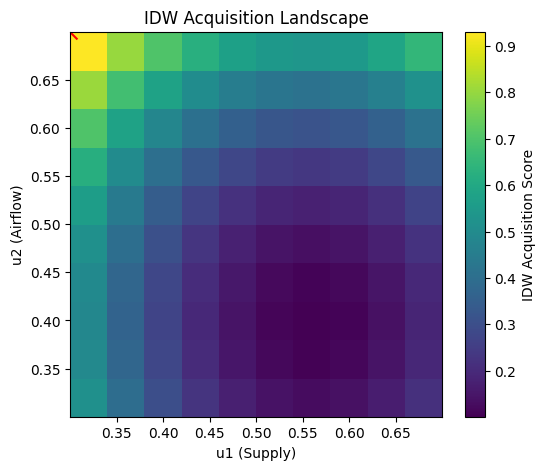

-------------------------------------------------------------------
Step counter = 1


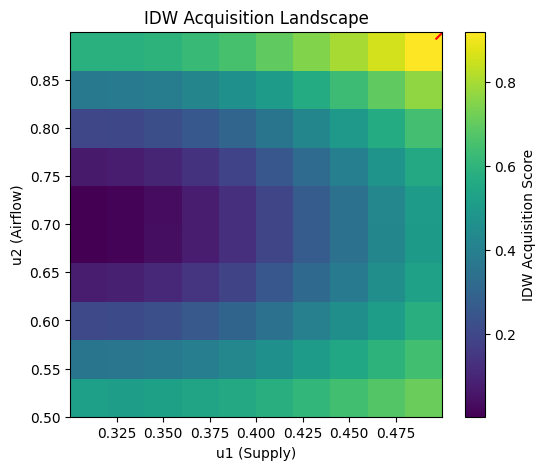

-------------------------------------------------------------------
Step counter = 2


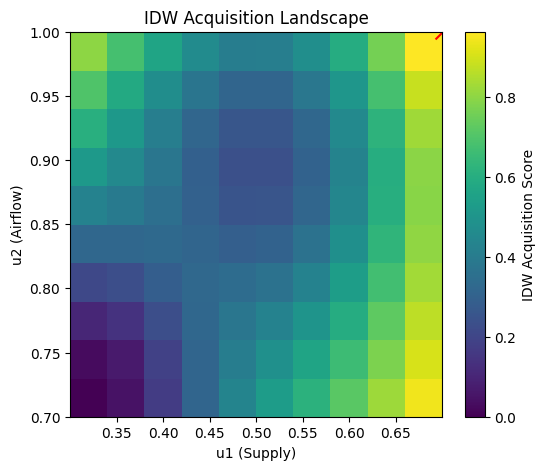

-------------------------------------------------------------------
Step counter = 3


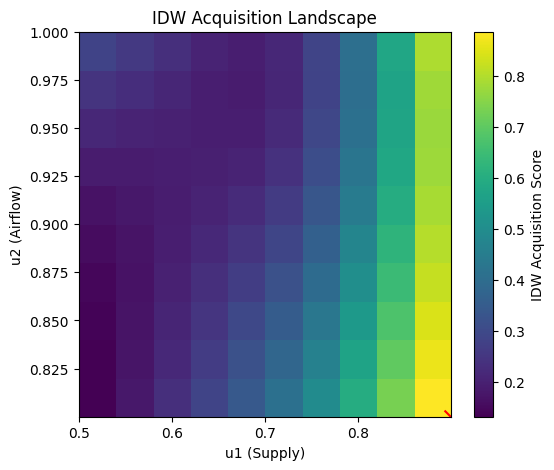

-------------------------------------------------------------------
Step counter = 4
-------------------------------------------------------------------
Step counter = 5
-------------------------------------------------------------------
Step counter = 6
-------------------------------------------------------------------
Step counter = 7
-------------------------------------------------------------------
Step counter = 8
-------------------------------------------------------------------
Step counter = 9
-------------------------------------------------------------------
Step counter = 10
-------------------------------------------------------------------
Step counter = 11
-------------------------------------------------------------------
Step counter = 12
-------------------------------------------------------------------
Step counter = 13
-------------------------------------------------------------------
Step counter = 14
------------------------------------------------------------

In [10]:
while y:
    x0 = y['zon_reaTRooAir_y']-273.15
    x_out = (y['zon_weaSta_reaWeaTDryBul_y']-273.15)
    print('-------------------------------------------------------------------')
    print('Step counter =', counter)
    counter += 1
    mpc_controller = MPC(trained_nn)
    if count < 5:
        plot = True
        count += 1
    if count >= 5:
        plot = False
    best_u, u = mpc_controller.mpc_grid_search(X_0=x0, X_out=x_out, u0_1=u0_1, u0_2=u0_2, n_grid=n_grid, X_tr=X_tr_new, y_tr=y_tr_new, plot=plot)
    y = requests.post('{0}/advance/{1}'.format(url, testid), json=u).json()['payload']  
    
    cur = to_tensor(x0).view(-1,1)/30.0
    T_sup_add = to_tensor((u['fcu_oveTSup_u']-273.15)/40.0).view(-1,1)
    fan_add = to_tensor(u['fcu_oveFan_u']).view(-1,1)
    pos_add = to_tensor(y['zon_reaTRooAir_y']-273.15).view(-1,1)/30.0
    T_out_add = to_tensor((y['zon_weaSta_reaWeaTDryBul_y']-273.15)/10.0).view(-1,1)
    X_tr_n = torch.cat((cur, T_sup_add, fan_add, T_out_add), dim=1)
    y_tr_n = pos_add.squeeze(-1)   

    X_tr_new = torch.cat((X_tr_new, X_tr_n), dim=0)
    y_tr_new = torch.cat((y_tr_new, y_tr_n), dim=0)
    
    if const.count_data == const.number_of_data:
        trained_nn = train_nn(model=trained_nn, X=X_tr_new, y=y_tr_new, epochs=const.epoch_onl, save_path=save_path)
        const.count_data = 0
    
    const.count_data += 1

    rmse = evaluate_NN(X_t, y_t, save_path=save_path)
    ls_rmse.append(rmse)

    u0_1 = (u['fcu_oveTSup_u']-273.15)/ 40.0
    u0_2 = u['fcu_oveFan_u']

    if counter > const.num_count:
        break

   zon_reaTRooAir_y  fcu_oveFan_u  fcu_oveTSup_u     time
0        295.310128           0.0         294.15  3801600
1        295.222125           0.5         293.15  3801630
2        295.117210           0.5         293.15  3801660
3        295.023884           0.5         293.15  3801690
4        294.940950           0.5         293.15  3801720


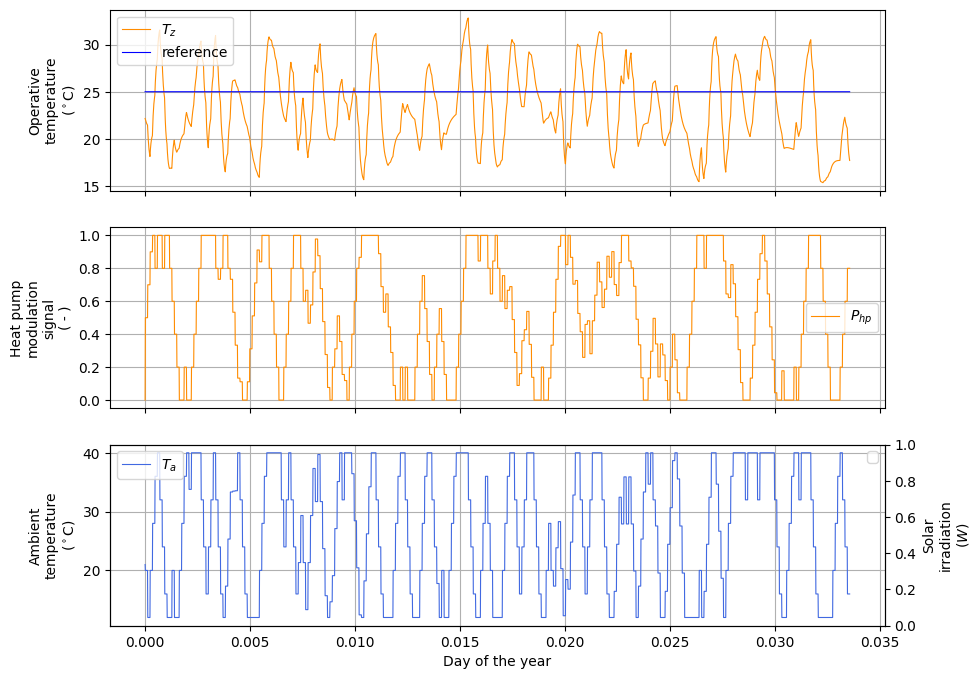

In [11]:
def get_and_plot_results(testid, start_time, final_time):
    df_res = pd.DataFrame()
    points = ['zon_reaTRooAir_y', 'fcu_oveFan_u', 'fcu_oveTSup_u']
    args = {'point_names':points,
            'start_time':start_time, 
            'final_time':final_time}
    res = requests.put('{0}/results/{1}'.format(url, testid), 
                        json=args).json()['payload']
    df_res = pd.DataFrame(data=res)
    print(df_res.head())
    df_res.set_index('time')
    plt.close()
    _, axs = plt.subplots(3, sharex=True, figsize=(10,8))
    x_time = df_res.index/3600./24.
    axs[0].plot(x_time, df_res['zon_reaTRooAir_y']    - 273.15, 'darkorange', linestyle='-', linewidth=0.8, label='$T_z$')
    axs[0].plot(x_time, np.full(len(df_res['zon_reaTRooAir_y']), x_ref), 'blue', linewidth=0.8, label='reference')
    axs[0].set_ylabel('Operative\ntemperature\n($^\circ$C)')
    axs[0].legend()
    axs[0].grid()

    axs[1].plot(x_time, df_res['fcu_oveFan_u'], 'darkorange', linestyle='-', linewidth=0.8, label='$P_{hp}$')
    axs[1].set_ylabel('Heat pump\nmodulation\nsignal\n( - )')
    axs[1].legend()
    axs[1].grid()

    axs[2].plot(x_time, df_res['fcu_oveTSup_u'] - 273.15, 'royalblue', linestyle='-', linewidth=0.8, label='$T_a$')
    axs[2].set_ylabel('Ambient\ntemperature\n($^\circ$C)')
    axs[2].legend(loc='upper left')
    axs[2].set_xlabel('Day of the year')
    axs[2].grid()
    axt = axs[2].twinx()
    axt.set_ylabel('Solar\nirradiation\n($W$)')
    axt.legend(loc='upper right')
    plt.show()  
    return None
get_and_plot_results(testid=testid, start_time=start_time_days*24*3600 + 0.0*24*3600, final_time=start_time_days*24*3600 + 10*24*3600)

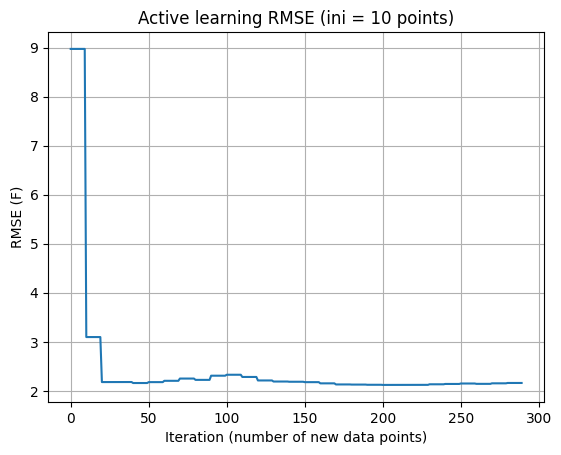

: 

In [ ]:
ls_rmse = [r.item()*30 for r in ls_rmse]    
plt.plot(ls_rmse)
plt.xlabel('Iteration (number of new data points)')
plt.grid()
plt.ylabel('RMSE (F)')
plt.title(f'Active learning RMSE (ini = {Ne_tr} points)')
plt.show()
import os
save_dir = 'results'
os.makedirs(save_dir, exist_ok=True)

df = pd.DataFrame(np.array(ls_rmse), columns=["RMSE_IDW_NN"])

save_path = f"RMSE_IDW_NN_ini{Ne_tr}_lr{const.lr}_ramp{const.ramp}.csv"                   
full_path = os.path.join(save_dir, save_path)               
df.to_csv(full_path, index=False)     